# **Fake News Detection Model Training - PolitiFact Only**

This notebook creates a BERT-based machine learning model trained EXCLUSIVELY on real PolitiFact fact-checked political articles (not synthetic data). This model specializes in detecting fake political news based on real-world fact-checking data.

The input files are:
1. PolitiFact fake articles: `../data/processed/politifact_sample_fake.csv`
2. PolitiFact real articles: `../data/processed/politifact_sample_real.csv`

Output:
- Trained model saved to: `../models/bert_politifact_retrained`
- This distinguishes it from `bert_political` which is trained on ISOT synthetic data

### Preparing Tools and Files

In [27]:
# ! pip install torch
# ! pip install transformers
# ! pip install numpy
# ! pip install pandas
# ! pip install datasets

In [28]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from datasets import Dataset

In [51]:
# Load ONLY full-length PolitiFact training data (highest quality, real articles)
import os

# Use absolute path to workspace
workspace_root = r'c:\Users\aweso\Documents\fakenews-analysis'
data_dir = os.path.join(workspace_root, 'data', 'processed', '00')
print(f"Loading data from: {data_dir}")

# ===== LOAD FULL-LENGTH TRAINING DATA ONLY =====
print("Loading full-length PolitiFact training data...")
train_file = os.path.join(data_dir, 'politifact_train.csv')
df = pd.read_csv(train_file)
df = df.rename(columns={'news': 'Article', 'label': 'Truth'})
df = df[['Article', 'Truth']].copy()

print(f"\n✅ TOTAL: {len(df)} articles loaded from PolitiFact training data")
print(f"\nClass distribution:")
print(df['Truth'].value_counts())
print(f"\nSample articles:")
df.head()

Loading data from: c:\Users\aweso\Documents\fakenews-analysis\data\processed\00
Loading full-length PolitiFact training data...

✅ TOTAL: 17090 articles loaded from PolitiFact training data

Class distribution:
Truth
0    9746
1    7344
Name: count, dtype: int64

Sample articles:

✅ TOTAL: 17090 articles loaded from PolitiFact training data

Class distribution:
Truth
0    9746
1    7344
Name: count, dtype: int64

Sample articles:


,Article,Truth
0,“Pennsylvania is under a court order to count ...,0
1,“Biden and Democrats have dismantled border se...,0
2,Katie Hobbs “has voted to double our gas tax. ...,1
3,Reuters reported that Nancy Pelosi bought 10 m...,0
4,"It's not true that ""the United States was buil...",0


### Preprocessing

The goal of preprocessing is to turn human-readable data into computer-readable training data.

First, we will check the dataset for missing parameters and remove them. We'll also allow you to select how much of the dataset you want to use for training.

In [52]:
df.isna().sum()

# Check class distribution
print("Class distribution:")
print(df['Truth'].value_counts())

Class distribution:
Truth
0    9746
1    7344
Name: count, dtype: int64


Now, we're going to trim down this dataset. Choose how many samples you want to use for training:

In [53]:
# 🎛️ DATASET SIZE SELECTOR - Choose how much data to train on
DATASET_SIZE = len(df)  # Set to full dataset size by default

print(f"Full dataset size: {len(df)}")

# Get balanced sample with equal fake and real news
fake_news = df[df['Truth'] == 0].head(DATASET_SIZE // 2)
real_news = df[df['Truth'] == 1].head(DATASET_SIZE // 2)
df = pd.concat([fake_news, real_news]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Selected dataset size: {len(df)}")

# Check balance after reduction
print(f"\nClass balance after reduction:")
print(df['Truth'].value_counts())

Full dataset size: 17090
Selected dataset size: 15889

Class balance after reduction:
Truth
0    8545
1    7344
Name: count, dtype: int64


Next, we'll tokenize the words. This takes the words and turns them into "tokens", chunks of information that can be read and understood by the computer.

In [54]:
# Create HuggingFace dataset
dataset = Dataset.from_pandas(df)

# Rename Truth column to labels (required by BERT model)
dataset = dataset.rename_column("Truth", "labels")

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["Article"], padding=True, truncation=True, max_length=256)

# Apply tokenizer
dataset_enc = dataset.map(tokenize, batched=True, remove_columns=["Article"])
dataset_enc = dataset_enc.train_test_split(test_size=0.2)

Map: 100%|██████████| 15889/15889 [00:15<00:00, 1047.00 examples/s]


Next, we want to convert these to pytorch tensors, objects that can be read by the pytorch library.

In [55]:
dataset_enc.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

The last few tools are the dataloaders and collators.

* The dataloaders will make sure we're sending small batches of articles/labels. The training data will be shuffled, making sure that the model isn't training for unintended patterns.

* The collator helps with efficiency of space and time by increasing the size of all tokens to the largest token in the batch.

In [56]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [57]:
# Dataloaders
train_dataloader = DataLoader(
    dataset_enc["train"], shuffle=True, batch_size=8, collate_fn=data_collator
)
eval_dataloader = DataLoader(
    dataset_enc["test"], batch_size=5, collate_fn=data_collator
)

## Processing

First we load the model to be trained.

In [58]:
num_labels = 2 # fake and real, or 0 and 1
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=num_labels
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Now let's define some parameters for how the model will train.

* learning rate: how much the model will adjust its weights based on error.

* epochs: how many times the model will go through the entire dataset.

**Training is made up of epochs, epochs are made up of batches, batches are made up of entries.**

In [59]:
batch_size = 8
max_length = 256
learning_rate = 2e-5
num_epochs = 10  # Increased from 5 to 10 for better convergence on PolitiFact data
warmup_ratio = 0.06
clip_grad = 1.0

# Calculate training steps - this was missing!
num_training_batches = len(train_dataloader)
num_training_steps = num_epochs * num_training_batches

print(f"Training configuration:")
print(f"- Epochs: {num_epochs}")
print(f"- Learning rate: {learning_rate}")
print(f"- Batch size: {batch_size}")
print(f"- Max token length: {max_length}")
print(f"- Total training steps: {num_training_steps}")

Training configuration:
- Epochs: 10
- Learning rate: 2e-05
- Batch size: 8
- Max token length: 256
- Total training steps: 15890


We'll set up a dynamic learning rate, shrinking over time as we get closer. Our first few runs will be rough, but as it gets better at prediction (lower loss), we want our adjustments to be smaller with it.

In [60]:
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=int(warmup_ratio * num_training_steps),
    num_training_steps=num_training_steps,
)

Now we specify which part of the computer will process this. We'll use CPU to avoid GPU memory issues and ensure stable training.

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")
model.train()

Using device: cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [63]:
# Model loading and training configuration
import os
model_save_path = '../models/bert_political_retrained'

# Option to retrain or use existing model
RETRAIN_MODEL = True  # Set to False if you want to use existing model without training

if os.path.exists(model_save_path) and not RETRAIN_MODEL:
    print("Loading pre-trained model...")
    model = AutoModelForSequenceClassification.from_pretrained(model_save_path)
    tokenizer = AutoTokenizer.from_pretrained(model_save_path)
    model.to(device)
    model.eval()  # Set to evaluation mode for inference only
    print("✅ Pre-trained model loaded successfully! Skipping training.")
else:
    if RETRAIN_MODEL:
        print("RETRAIN_MODEL is True - Starting fresh training...")
    else:
        print("No pre-trained model found. Starting fresh training...")
    
    # Use the fresh model we already initialized above
    model.train()  # Ensure model is in training mode
    print(f"✅ Model ready for training on {device}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

RETRAIN_MODEL is True - Starting fresh training...
✅ Model ready for training on cuda
Model parameters: 109,483,778


Training Loop:

Epoch 1 of 10


Training Epoch 1: 100%|██████████| 1589/1589 [08:13<00:00,  3.22it/s]


Epoch 1 loss: 0.5619
Epoch 2 of 10


Training Epoch 2: 100%|██████████| 1589/1589 [07:53<00:00,  3.36it/s]


Epoch 2 loss: 0.4631
Epoch 3 of 10


...

Epoch 8 loss: 0.0279
Epoch 9 of 10


Training Epoch 9: 100%|██████████| 1589/1589 [08:06<00:00,  3.27it/s]


Epoch 9 loss: 0.0143
Epoch 10 of 10


Training Epoch 10: 100%|██████████| 1589/1589 [07:45<00:00,  3.42it/s]

Epoch 10 loss: 0.0088


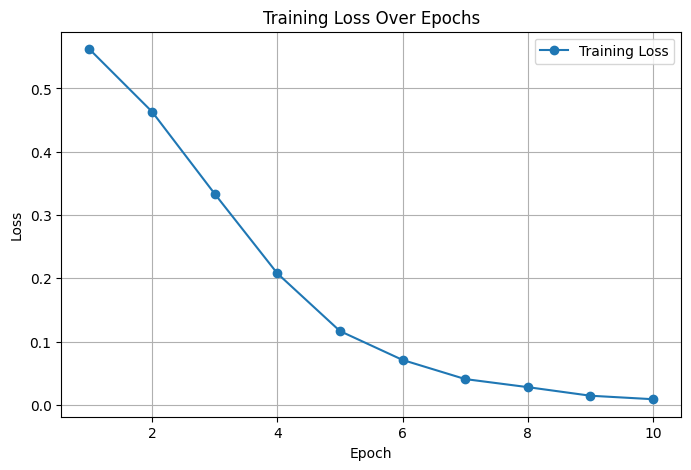

In [64]:
import matplotlib.pyplot as plt

train_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    
    print(f"Epoch {epoch + 1} of {num_epochs}")
    
    for batch in tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        
        optimizer.step()
        scheduler.step()  # Changed from lr_scheduler to scheduler
        optimizer.zero_grad()
        
        train_loss += loss.item()
    
    avg_loss = train_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

To keep persistent, save the weights to a file

In [66]:
# Save as bert_politifact_retrained to distinguish from ISOT-trained bert_political model
model_save_path = '../../models/bert_politifact_retrained'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✅ Model saved to {model_save_path}")
print(f"This model is trained on comprehensive PolitiFact training data (17,090 articles)")

✅ Model saved to ../../models/bert_politifact_retrained
This model is trained on comprehensive PolitiFact training data (17,090 articles)


## Model Evaluation and Analysis

Now let's comprehensively evaluate our trained BERT model using multiple metrics and visualizations.

In [67]:
# Import additional libraries for evaluation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
import seaborn as sns

print("=== BERT Model Evaluation ===")
print("Calculating comprehensive metrics...")

=== BERT Model Evaluation ===
Calculating comprehensive metrics...


In [68]:
# Evaluation Function
def evaluate_model(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []
    prediction_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            logits = outputs.logits
            
            # Get probabilities and predictions
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)
            
            # Store results
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['labels'].cpu().numpy())
            prediction_probs.extend(probs.cpu().numpy())
    
    return np.array(true_labels), np.array(predictions), np.array(prediction_probs)

# Run evaluation on test set
print("Evaluating on test set...")
true_labels, predictions, probs = evaluate_model(model, eval_dataloader, device)

Evaluating on test set...


Evaluating: 100%|██████████| 636/636 [00:32<00:00, 19.39it/s]


In [74]:
# Calculate All Metrics
print("\n=== COMPREHENSIVE METRICS ===")

# Basic metrics
accuracy = accuracy_score(true_labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='weighted')

# ROC-AUC (using probabilities for positive class)
roc_auc = roc_auc_score(true_labels, probs[:, 1])

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Detailed classification report
print(f"\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predictions, target_names=['Fake News', 'Real News']))


=== COMPREHENSIVE METRICS ===
Accuracy:  0.7486
Precision: 0.7514
Recall:    0.7486
F1-Score:  0.7489
ROC-AUC:   0.8197

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Fake News       0.79      0.73      0.76      1696
   Real News       0.71      0.77      0.74      1482

    accuracy                           0.75      3178
   macro avg       0.75      0.75      0.75      3178
weighted avg       0.75      0.75      0.75      3178




=== CONFUSION MATRIX ===


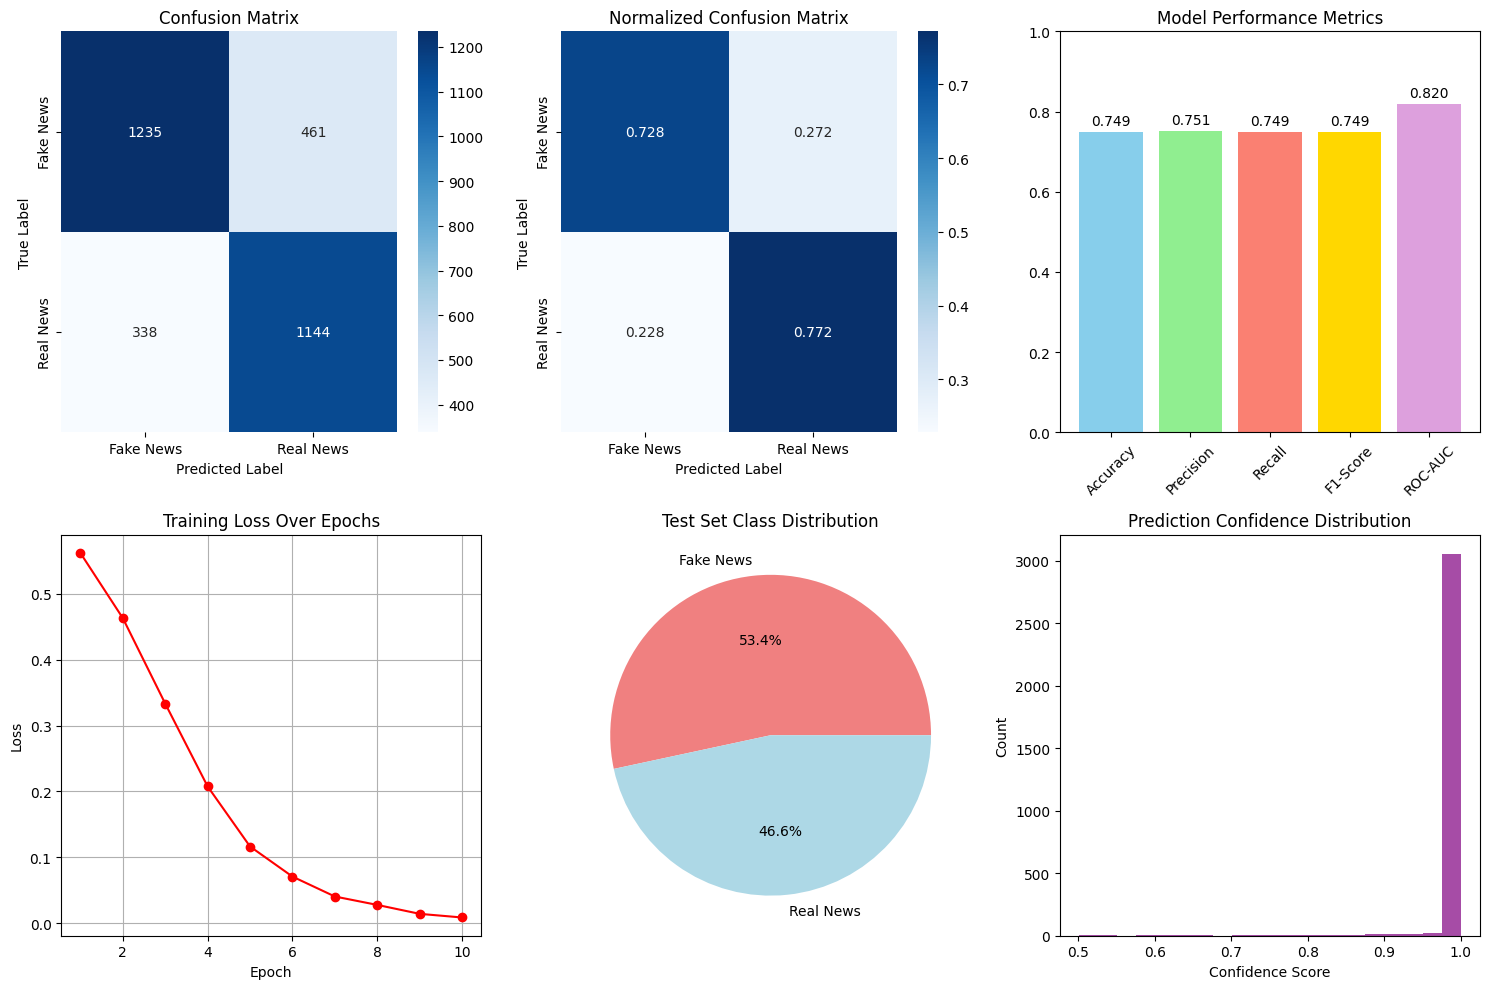


Confusion Matrix Breakdown:
True Negatives (Correctly predicted Fake): 1235
False Positives (Fake predicted as Real): 461
False Negatives (Real predicted as Fake): 338
True Positives (Correctly predicted Real): 1144

Sensitivity (True Positive Rate): 0.7719
Specificity (True Negative Rate): 0.7282


In [75]:
# Generate and Visualize Confusion Matrix
print("\n=== CONFUSION MATRIX ===")

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Create visualization
plt.figure(figsize=(15, 10))

# Confusion Matrix Plot
plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Normalized Confusion Matrix
plt.subplot(2, 3, 2)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Metrics Comparison Bar Chart
plt.subplot(2, 3, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'gold', 'plum'])
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom')

# Training Loss Curve
plt.subplot(2, 3, 4)
if 'train_losses' in locals():
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='red')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

# Class Distribution
plt.subplot(2, 3, 5)
class_counts = [np.sum(true_labels == 0), np.sum(true_labels == 1)]
plt.pie(class_counts, labels=['Fake News', 'Real News'], autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Test Set Class Distribution')

# Prediction Confidence Distribution
plt.subplot(2, 3, 6)
confidence_scores = np.max(probs, axis=1)
plt.hist(confidence_scores, bins=20, alpha=0.7, color='purple')
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print confusion matrix details
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted Fake): {cm[0,0]}")
print(f"False Positives (Fake predicted as Real): {cm[0,1]}")
print(f"False Negatives (Real predicted as Fake): {cm[1,0]}")
print(f"True Positives (Correctly predicted Real): {cm[1,1]}")

# Calculate additional metrics
sensitivity = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0

print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

In [22]:
# K-Fold Cross-Validation
print("\n=== K-FOLD CROSS-VALIDATION ===")

# Prepare data for K-fold
X = df['Article'].values
y = df['Truth'].values

# Initialize K-fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
cv_accuracies = []
cv_f1_scores = []
cv_precisions = []
cv_recalls = []
cv_roc_aucs = []

print("Running 5-fold cross-validation...")
print("Note: This will take several minutes as we train 5 mini-models")

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"\nFold {fold + 1}/5")
    
    # Split data
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    # Create datasets
    train_df_fold = pd.DataFrame({'Article': X_train_fold, 'labels': y_train_fold})
    val_df_fold = pd.DataFrame({'Article': X_val_fold, 'labels': y_val_fold})
    
    train_dataset_fold = Dataset.from_pandas(train_df_fold)
    val_dataset_fold = Dataset.from_pandas(val_df_fold)
    
    # Tokenize
    train_dataset_fold = train_dataset_fold.map(tokenize, batched=True, remove_columns=['Article'])
    val_dataset_fold = val_dataset_fold.map(tokenize, batched=True, remove_columns=['Article'])
    
    # Set format
    train_dataset_fold.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    val_dataset_fold.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    
    # Create dataloaders
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=8, shuffle=True, collate_fn=data_collator)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=8, collate_fn=data_collator)
    
    # Create new model for this fold
    model_fold = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    model_fold.to(device)
    
    # Quick training (1 epoch for demo - you can increase this for better results)
    optimizer_fold = AdamW(model_fold.parameters(), lr=learning_rate)
    model_fold.train()
    
    # Mini training loop
    for batch in tqdm(train_loader_fold, desc=f"Training Fold {fold+1}", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model_fold(**batch)
        loss = outputs.loss
        loss.backward()
        
        optimizer_fold.step()
        optimizer_fold.zero_grad()
    
    # Evaluate fold
    fold_true, fold_pred, fold_probs = evaluate_model(model_fold, val_loader_fold, device)
    
    # Calculate metrics
    fold_acc = accuracy_score(fold_true, fold_pred)
    fold_prec, fold_rec, fold_f1, _ = precision_recall_fscore_support(fold_true, fold_pred, average='weighted')
    fold_auc = roc_auc_score(fold_true, fold_probs[:, 1])
    
    # Store results
    cv_accuracies.append(fold_acc)
    cv_f1_scores.append(fold_f1)
    cv_precisions.append(fold_prec)
    cv_recalls.append(fold_rec)
    cv_roc_aucs.append(fold_auc)
    
    print(f"  Accuracy: {fold_acc:.4f}, F1: {fold_f1:.4f}, ROC-AUC: {fold_auc:.4f}")

# Print cross-validation results
print(f"\n=== CROSS-VALIDATION SUMMARY ===")
print(f"Accuracy:  {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"Precision: {np.mean(cv_precisions):.4f} ± {np.std(cv_precisions):.4f}")
print(f"Recall:    {np.mean(cv_recalls):.4f} ± {np.std(cv_recalls):.4f}")
print(f"F1-Score:  {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"ROC-AUC:   {np.mean(cv_roc_aucs):.4f} ± {np.std(cv_roc_aucs):.4f}")

# Visualize cross-validation results
plt.figure(figsize=(12, 8))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
cv_means = [np.mean(cv_accuracies), np.mean(cv_precisions), np.mean(cv_recalls), 
           np.mean(cv_f1_scores), np.mean(cv_roc_aucs)]
cv_stds = [np.std(cv_accuracies), np.std(cv_precisions), np.std(cv_recalls), 
          np.std(cv_f1_scores), np.std(cv_roc_aucs)]

plt.errorbar(metrics_names, cv_means, yerr=cv_stds, fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=8)
plt.title('Cross-Validation Results with Standard Deviation')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


=== K-FOLD CROSS-VALIDATION ===
Running 5-fold cross-validation...
Note: This will take several minutes as we train 5 mini-models

Fold 1/5


Map: 100%|██████████| 8771/8771 [00:01<00:00, 6435.76 examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
                                                                  

KeyboardInterrupt: 

## Interactive Model Testing

Test the model with your own custom articles! Input any article text and the true label to see how well the model performs.

In [76]:
# Function to test custom articles
def test_custom_article(article_text, true_label, model, tokenizer, device):
    """
    Test a custom article with the trained model
    
    Args:
        article_text (str): The article text to test
        true_label (int): The true label (0 = fake, 1 = real)
        model: The trained BERT model
        tokenizer: The BERT tokenizer
        device: The device (CPU/GPU)
    
    Returns:
        dict: Results including prediction, confidence, and accuracy
    """
    # Ensure model is in evaluation mode
    model.eval()
    
    # Tokenize the input
    inputs = tokenizer(
        article_text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    
    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get prediction
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Get probabilities and prediction
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(logits, dim=-1).item()
        confidence = torch.max(probs).item()
        
        # Get probability for each class
        fake_prob = probs[0][0].item()
        real_prob = probs[0][1].item()
    
    # Create results
    results = {
        'article_text': article_text,
        'true_label': true_label,
        'predicted_label': prediction,
        'confidence': confidence,
        'fake_probability': fake_prob,
        'real_probability': real_prob,
        'correct': true_label == prediction,
        'true_class': 'Real News' if true_label == 1 else 'Fake News',
        'predicted_class': 'Real News' if prediction == 1 else 'Fake News'
    }
    
    return results

# Display function for results
def display_test_results(results):
    """Display the test results in a formatted way"""
    print("=" * 80)
    print("🔍 CUSTOM ARTICLE TEST RESULTS")
    print("=" * 80)
    
    # Status indicator
    status = "✅ CORRECT" if results['correct'] else "❌ INCORRECT"
    print(f"Status: {status}")
    print()
    
    # Labels
    print(f"True Label:      {results['true_class']}")
    print(f"Predicted Label: {results['predicted_class']}")
    print()
    
    # Probabilities
    print(f"Confidence: {results['confidence']:.4f}")
    print(f"Fake News Probability: {results['fake_probability']:.4f}")
    print(f"Real News Probability: {results['real_probability']:.4f}")
    print()
    
    # Article preview
    article_preview = results['article_text'][:300] + "..." if len(results['article_text']) > 300 else results['article_text']
    print(f"Article Text (preview):")
    print(f'"{article_preview}"')
    print("=" * 80)

print("✅ Custom article testing functions defined!")

✅ Custom article testing functions defined!


### Test Examples

Here are some examples of how to test custom articles. You can modify these or add your own!

In [78]:
# Example 1: Test with a fake news article
fake_article = """
Breaking: Scientists discover that drinking coffee while standing on one foot 
can increase your IQ by 50 points! A new study from the University of Made-Up 
Research claims that this simple technique, practiced for just 5 minutes daily, 
can dramatically boost cognitive function. The study, which has not been peer-reviewed, 
involved 12 participants and was funded by a coffee company.
"""

# Test the fake article (true label = 0 for fake)
fake_results = test_custom_article(fake_article, true_label=0, model=model, tokenizer=tokenizer, device=device)
display_test_results(fake_results)

🔍 CUSTOM ARTICLE TEST RESULTS
Status: ✅ CORRECT

True Label:      Fake News
Predicted Label: Fake News

Confidence: 1.0000
Fake News Probability: 1.0000
Real News Probability: 0.0000

Article Text (preview):
"
Breaking: Scientists discover that drinking coffee while standing on one foot 
can increase your IQ by 50 points! A new study from the University of Made-Up 
Research claims that this simple technique, practiced for just 5 minutes daily, 
can dramatically boost cognitive function. The study, which ..."


In [79]:
# Example 2: Test with a real news article
real_article = """
The Federal Reserve announced today that it will maintain interest rates at their current level
following a two-day meeting of the Federal Open Market Committee. Fed Chair Jerome Powell stated
in a press conference that the decision reflects ongoing concerns about inflation while balancing
the need to support economic growth. The announcement was widely expected by economists and
had minimal impact on stock markets. The next Fed meeting is scheduled for next month.
"""

# Test the real article (true label = 1 for real)
real_results = test_custom_article(real_article, true_label=1, model=model, tokenizer=tokenizer, device=device)
display_test_results(real_results)

🔍 CUSTOM ARTICLE TEST RESULTS
Status: ✅ CORRECT

True Label:      Real News
Predicted Label: Real News

Confidence: 1.0000
Fake News Probability: 0.0000
Real News Probability: 1.0000

Article Text (preview):
"
The Federal Reserve announced today that it will maintain interest rates at their current level
following a two-day meeting of the Federal Open Market Committee. Fed Chair Jerome Powell stated
in a press conference that the decision reflects ongoing concerns about inflation while balancing
the need..."


### Your Custom Test

Use this cell to test your own articles! Just replace the text and true label below.

In [85]:
# 📝 YOUR CUSTOM ARTICLE TEST
# Replace the article text and true_label below with your own test case

# Your article text here
your_article = """
PARSIPPANY, NJ—Claiming that the recent spate of mass shootings gave them no choice but to stand up and try to make a difference, vegetable purveyor Green Giant launched a new program Friday where gun owners can trade in their firearms in exchange for green beans. “These kinds of weapons have no place on the street or in our homes, which is why Green Giant is stepping up and offering 25 pounds of green beans for any semi-automatic weapon turned over to us,” said spokesperson Gina Sorpino, adding that a new ad campaign running in every major market promised gun owners who turned in multiple weapons could receive premium products like their Italian herb vegetable medley and fire-roasted sautéed zucchini. “We don’t want to force people to give up their guns, and we think our flavorful, healthy green beans are just the incentive people need. You can snack on them, put them in a casserole, even grill them. And unlike guns, the fatalities caused by green beans are almost non-existent. We hope gun owners will join Green Giant in building a safer world for our children.” At press time, Green Giant had discontinued the program after receiving over 5 million death threats."""

# Your true label here (0 = fake news, 1 = real news)
your_true_label = 0  # Change this to 0 (fake) or 1 (real)

# Test your article
your_results = test_custom_article(your_article, true_label=your_true_label, model=model, tokenizer=tokenizer, device=device)
display_test_results(your_results)

🔍 CUSTOM ARTICLE TEST RESULTS
Status: ✅ CORRECT

True Label:      Fake News
Predicted Label: Fake News

Confidence: 0.9203
Fake News Probability: 0.9203
Real News Probability: 0.0797

Article Text (preview):
"
PARSIPPANY, NJ—Claiming that the recent spate of mass shootings gave them no choice but to stand up and try to make a difference, vegetable purveyor Green Giant launched a new program Friday where gun owners can trade in their firearms in exchange for green beans. “These kinds of weapons have no pl..."
